Para hacer un EDA completo con visualizaciones, es necesario importar las librerías necesarias. 
En este caso, se importan pandas para el manejo de datos, seaborn para la visualización, plotly para gráficos interactivos
 y numpy para operaciones numéricas.

In [1]:
# imports ordenados
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
# cargamos los datos con pandas desde la url
url = "https://gist.githubusercontent.com/alansastre/1d8b938fb2e1e6c2798203637d8361c5/raw/bdb0edd1421db22265235cd11042503c14fabdb1/taxis.csv"

df = pd.read_csv(url,  encoding='utf-8') # añadimos encoding para evitar problemas con caracteres especiales.

print(df.head()) # compruebo estructura del dataset.

   Trip_Distance_km Time_of_Day Day_of_Week  Passenger_Count  \
0             19.35     Morning     Weekday              3.0   
1             47.59   Afternoon     Weekday              1.0   
2             36.87     Evening     Weekend              1.0   
3             30.33     Evening     Weekday              4.0   
4               NaN     Evening     Weekday              3.0   

  Traffic_Conditions Weather  Base_Fare  Per_Km_Rate  Per_Minute_Rate  \
0                Low   Clear       3.56         0.80             0.32   
1               High   Clear        NaN         0.62             0.43   
2               High   Clear       2.70         1.21             0.15   
3                Low     NaN       3.48         0.51             0.15   
4               High   Clear       2.93         0.63             0.32   

   Trip_Duration_Minutes  Trip_Price  
0                  53.82     36.2624  
1                  40.57         NaN  
2                  37.27     52.9032  
3                 11

In [3]:
# analizamos el dataset con shape, info, describe y dtypes para ver la estructura de los datos y sus tipos
print("\n|shape|")
print(df.shape)

print("\n|info|")
print(df.info())

print("\n|describe|")
print(df.describe())

print("\n|dtypes|")
print(df.dtypes)


|shape|
(1000, 11)

|info|
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    str    
 2   Day_of_Week            950 non-null    str    
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    str    
 5   Weather                950 non-null    str    
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), str(4)
memory usage: 86.1 KB
None

|describe|
       Trip_Distance_km  Passenger_Count   Base_Fare  Per_Km_Rate  \
count        950.000000       950.000000  950.000000   950.000000 

In [4]:
# conteo de valores nulos
print("\n|valores nulos por columna|")
print(df.isnull().sum())

# porcentaje de valores nulos por columna
print("\n|porcentaje de valores nulos por columna|")
print((df.isna().sum() / len(df) * 100).round(2))


|valores nulos por columna|
Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

|porcentaje de valores nulos por columna|
Trip_Distance_km         5.0
Time_of_Day              5.0
Day_of_Week              5.0
Passenger_Count          5.0
Traffic_Conditions       5.0
Weather                  5.0
Base_Fare                5.0
Per_Km_Rate              5.0
Per_Minute_Rate          5.0
Trip_Duration_Minutes    5.0
Trip_Price               4.9
dtype: float64


Hacemos limpieza de nulos copiando el dataframe para no comprometerlo, e identificamos la variable a predecir.

In [5]:
# elimino filas con valores nulos en Trip_Price
df_clean = df.dropna(subset=["Trip_Price"]).copy()

print(f"\n|filas después de limpieza: {len(df_clean)}|")

print(f"|valores nulos restantes: {df_clean.isnull().sum().sum()}|")


|filas después de limpieza: 951|
|valores nulos restantes: 472|


In [6]:
# comprobamos la estructura del dataset limpio
print(df_clean.info())
print(f"\n|forma de df_clean: {df_clean.shape}|")

<class 'pandas.DataFrame'>
Index: 951 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       901 non-null    float64
 1   Time_of_Day            902 non-null    str    
 2   Day_of_Week            905 non-null    str    
 3   Passenger_Count        903 non-null    float64
 4   Traffic_Conditions     901 non-null    str    
 5   Weather                905 non-null    str    
 6   Base_Fare              907 non-null    float64
 7   Per_Km_Rate            907 non-null    float64
 8   Per_Minute_Rate        902 non-null    float64
 9   Trip_Duration_Minutes  905 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), str(4)
memory usage: 89.2 KB
None

|forma de df_clean: (951, 11)|


In [7]:
print("\n|describe después de limpieza|")
print(df_clean.describe().T)


|describe después de limpieza|
                       count       mean        std     min       25%      50%  \
Trip_Distance_km       901.0  27.190998  20.155134  1.2300  12.63000  25.8700   
Passenger_Count        903.0   2.479513   1.100983  1.0000   2.00000   2.0000   
Base_Fare              907.0   3.497100   0.866729  2.0100   2.73000   3.5100   
Per_Km_Rate            907.0   1.229934   0.429958  0.5000   0.85000   1.2200   
Per_Minute_Rate        902.0   0.293902   0.115404  0.1000   0.19000   0.2900   
Trip_Duration_Minutes  905.0  62.044144  32.321578  5.0100  35.59000  61.5700   
Trip_Price             951.0  56.874773  40.469791  6.1269  33.74265  50.0745   

                            75%         max  
Trip_Distance_km       38.68000  146.067047  
Passenger_Count         3.00000    4.000000  
Base_Fare               4.23000    5.000000  
Per_Km_Rate             1.61000    2.000000  
Per_Minute_Rate         0.39000    0.500000  
Trip_Duration_Minutes  89.21000  119.840000

<Axes: xlabel='Trip_Price', ylabel='Count'>

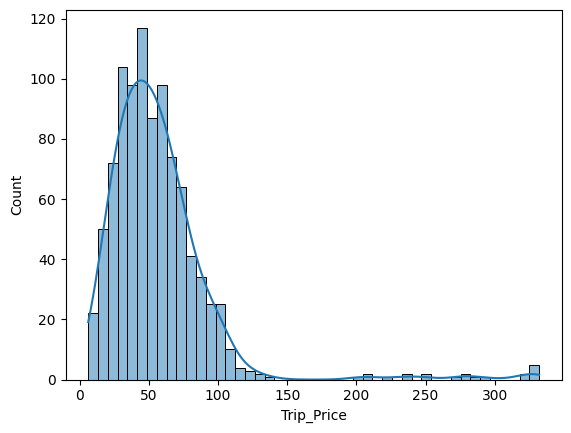

In [8]:
# visualizamos la distribución de Trip_Price con un histograma
df_clean = df.dropna(subset=["Trip_Price"]).copy()
sns.histplot(data=df_clean, x="Trip_Price", kde=True)

La mayoría de los viajes se concentran en precios bajos,
pero vale la pena mencionar la existencia de viajes caros en los extremos (los llamaremos outliers),
datos a tener en cuenta al momento de entrenar el modelo.

In [9]:
# dibujamos un boxplot
fig = px.box(
    df_clean,
    y="Trip_Price",
    title="Boxplot de Trip_Price"
)

fig.update_layout(
    yaxis_title="Precio del viaje"
)

fig.show()

Este boxplot nos permite identificar posibles outliers en la variable Trip_Price.
Los puntos por encima del upper fence indican los viajes con precios atípicos frente a los demás viajes.

In [10]:
# identificamos las columnas numéricas y categóricas
columnas_numericas = df_clean.select_dtypes(include="number").columns.drop("Trip_Price")
columnas_categoricas = df_clean.select_dtypes(include=["object", "string"]).columns

print("\n|columnas numericas|")
print(columnas_numericas)

print("\n|columnas categoricas|")
print(columnas_categoricas)


|columnas numericas|
Index(['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes'],
      dtype='str')

|columnas categoricas|
Index(['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather'], dtype='str')


In [11]:
# aquí rellenamos los valores nulos de las columnas numéricas con la media de cada columna
for column in columnas_numericas:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mean())

In [12]:
# aquí rellenamos los valores nulos de las columnas categóricas con la moda de cada columna
for column in columnas_categoricas:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

In [13]:
# verificamos que no queden valores nulos
print("\n|valores nulos despues de rellenar|")
print(df_clean.isnull().sum())

print("\n|total de nulos restantes|")
print(df_clean.isnull().sum().sum())


|valores nulos despues de rellenar|
Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

|total de nulos restantes|
0


In [14]:
# no usar print me deja ver mejor el dataframe
df_clean.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
2,36.870000,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.330000,Evening,Weekday,4.0,Low,Clear,3.48,0.51,0.15,116.81,36.4698
4,27.190998,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
5,8.640000,Afternoon,Weekend,2.0,Medium,Clear,2.55,1.71,0.48,89.33,60.2028


In [15]:
# visualizamos la distribución de Trip_Price con un histograma interactivo
fig = px.histogram(df_clean, 
                   x="Trip_Price", 
                   nbins=30, 
                   title="distribución de Trip_Price"
                   )

fig.update_traces(marker_color='blue')
fig.update_layout(
    xaxis_title="Trip_Price in USD",
    yaxis_title="frecuencia in trips",
)

fig.show()

Esta gráfica nos muestra la concentración de los viajes y sus precios más frecuentes, indicando que hay muy pocos viajes por encima de los 200 USD,
pero muchos en el rango aproximado de 0 USD a 100 USD.

In [16]:
# visualizamos la relación entre Trip_Price y Base_Fare con un scatter plot interactivo
fig = px.scatter(
    df_clean,
    x="Trip_Price",
    y="Base_Fare",
    opacity=0.6,
    title="Trip_Price vs Base_Fare"
)
fig.show()

Este scatter plot nos muestra la relación entre 'Trip_Price' y 'Base_Fare'.
Aunque 'Base_Fare' forma parte del coste del viaje, no parece explicar por sí sola el precio del mismo, pues los puntos están bastante dispersos, 
y no se logra ver un patrón o tendencia lineal clara.

Text(0.5, 1.0, 'Matriz de correlación de df_clean')

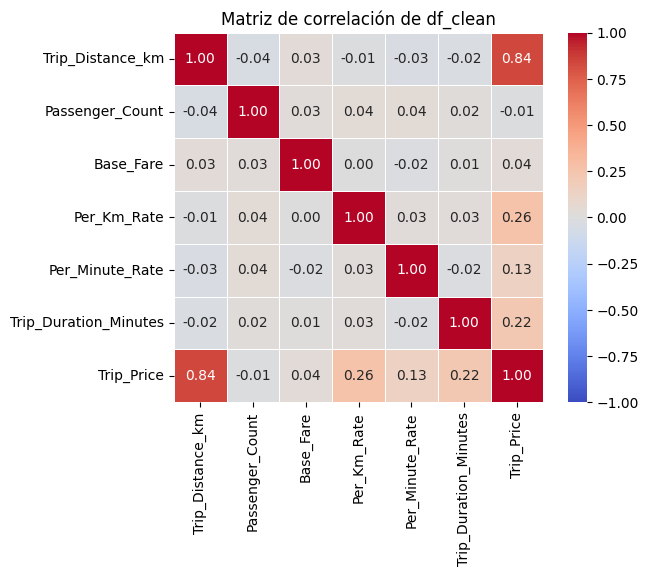

In [17]:
# hacemos una matriz de correlación solo con columnas numéricas
corr = df_clean.select_dtypes(include="number").corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(
    corr,
   # mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

ax.set_title("Matriz de correlación de df_clean")

Este heatmap sí nos muestra una fuerte correlación entre el precio del viaje y la distancia en km del viaje con 0.84,
indicando que, a mayor distancia recorrida, mayor tiende a ser el precio del viaje.

Aunque otras variables también muestren una correlación positiva (tarifa por km, tarifa por minuto, duración del viaje en minutos), la que mayor peso tendría es
'Trip_Distance_km'

In [18]:
# aplico encoding a las columnas categóricas para poder hacer análisis de correlación con ellas
traffic_dummies = pd.get_dummies(df_clean["Traffic_Conditions"], prefix="Traffic_Conditions", drop_first=True)
weather_dummies = pd.get_dummies(df_clean["Weather"], prefix="Weather", drop_first=True)

# concateno las columnas numéricas y las dummies de las columnas categóricas
df_encoded = pd.concat([df_clean.select_dtypes(include="number"), traffic_dummies, weather_dummies], axis=1)
df_encoded.head()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
0,19.350000,3.0,3.56,0.80,0.32,53.82,36.2624,True,False,False,False
2,36.870000,1.0,2.70,1.21,0.15,37.27,52.9032,False,False,False,False
3,30.330000,4.0,3.48,0.51,0.15,116.81,36.4698,True,False,False,False
4,27.190998,3.0,2.93,0.63,0.32,22.64,15.6180,False,False,False,False
5,8.640000,2.0,2.55,1.71,0.48,89.33,60.2028,False,True,False,False


In [19]:
# correlación entre Trip_Price y condiciones de clima
corr_weather = df_encoded[["Trip_Price"] + list(weather_dummies.columns)].corr()
print("\n|correlación entre Trip_Price y condiciones de clima|")
print(corr_weather["Trip_Price"])


|correlación entre Trip_Price y condiciones de clima|
Trip_Price      1.000000
Weather_Rain    0.038793
Weather_Snow    0.005764
Name: Trip_Price, dtype: float64


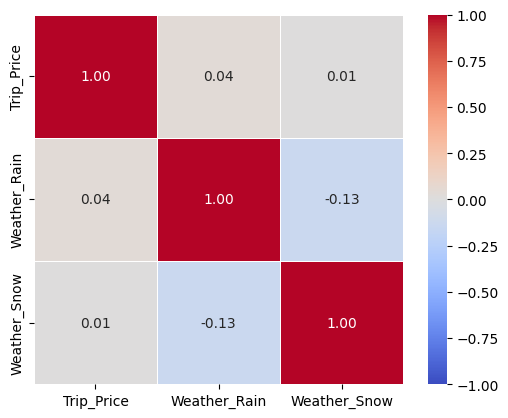

In [20]:
# visualizamos la correlación entre Trip_Price y condiciones de clima con un heatmap
ax_test = sns.heatmap(
    corr_weather,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

Esta gráfica nos muestra que las condiciones del clima no muestran una relación lineal relevante (en este análisis, al menos) 
ya que la correlación es muy baja.
Por lo tanto, de forma aislada, las condiciones climáticas no explican directamente el precio del viaje.

Text(0.5, 1.0, 'Matriz de correlación de df_encoded')

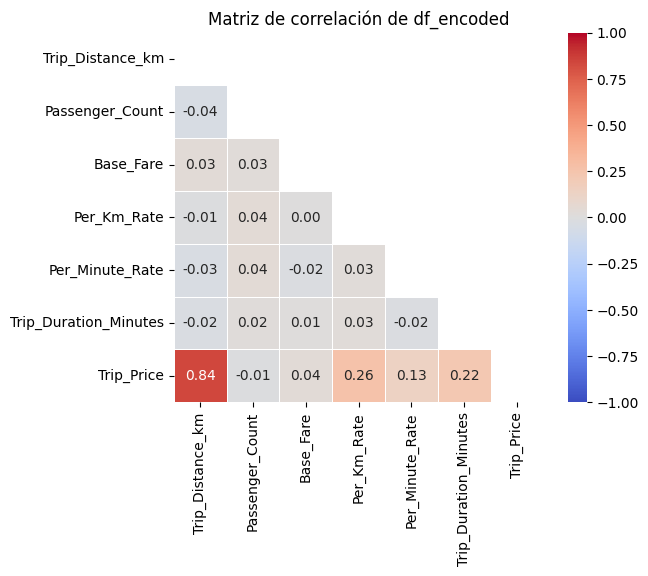

In [21]:
# correlación solo con columnas numéricas
corr = df_encoded.select_dtypes(include="number").corr()

# mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

ax.set_title("Matriz de correlación de df_encoded")

Aquí vemos otra matriz de correlación en forma de heatmap, usando 'mask' para mostrar la mitad útil del gráfico.

In [22]:
corr.head()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
Trip_Distance_km,1.000000,-0.042474,0.031650,-0.013731,-0.032466,-0.023696,0.841360
Passenger_Count,-0.042474,1.000000,0.027432,0.042327,0.042410,0.016758,-0.013941
Base_Fare,0.031650,0.027432,1.000000,0.000818,-0.017322,0.009361,0.035156
Per_Km_Rate,-0.013731,0.042327,0.000818,1.000000,0.025157,0.028251,0.263598
Per_Minute_Rate,-0.032466,0.042410,-0.017322,0.025157,1.000000,-0.022396,0.134154


In [23]:
fig = px.scatter(
    df_clean,
    x="Trip_Distance_km",
    y="Trip_Price",
    title="Relación entre Trip_Distance_km y Trip_Price",
    opacity=0.6
)

fig.update_layout(
    xaxis_title="Trip_Distance_km",
    yaxis_title="Trip_Price"
)

fig.show()

Este scatter plot nos muestra una concentración de los viajes en un rango de distancia entre 0 km y 50 km, con precios respectivos desde 0 USD hasta los 150 USD aproximadamente.
También existen outliers, que muestran pocos viajes con distancia > 100km y precios por encima de los 200 USD.

In [24]:
fig = px.scatter(
    df_clean,
    x="Trip_Duration_Minutes",
    y="Trip_Price",
    title="Relación entre Trip_Duration_Minutes y Trip_Price",
    opacity=0.6
)

fig.update_layout(
    xaxis_title="Trip_Duration_Minutes",
    yaxis_title="Trip_Price"
)

fig.show()

Este scatter plot nos indica que la duración es también una métrica débil y no tan lineal para predecir el precio del viaje.

In [25]:
df_clean["Trip_Duration_Minutes"].corr(df_clean["Trip_Price"])

np.float64(0.21930546447234278)

In [26]:
# visualizamos la relación entre Trip_Price y Traffic_Conditions con un gráfico de barras interactivo
precio_medio_trafico = (
    df_clean
    .groupby("Traffic_Conditions")["Trip_Price"]
    .mean()
    .reset_index()
    .sort_values("Trip_Price", ascending=False)
)

fig = px.bar(
    precio_medio_trafico,
    x="Traffic_Conditions",
    y="Trip_Price",
    title="Precio medio del viaje según condiciones de tráfico",
    text_auto=".2f"
)

fig.update_layout(
    xaxis_title="Condiciones de tráfico",
    yaxis_title="Precio medio del viaje"
)

fig.show()

Esta gráfica compara los precios medios de los viajes según las condiciones de tráfico, indicando poca variabilidad en la variable a predecir,
en comparación a otras variables numéricas que pueden afectar más el precio del viaje, como la duración del viaje,
distancia en km o tarifas.

In [27]:
# aquí hacemos encoding de las columnas categóricas porque el modelo de regresión lineal no puede trabajar con texto
df_encoded = pd.get_dummies(df_clean, columns=columnas_categoricas, drop_first=True)

In [28]:
# separamos X de y de la variable objetivo
X = df_encoded.drop("Trip_Price", axis=1)
y = df_encoded["Trip_Price"]

In [29]:
# aquí dividimos los datos en entrenamiento y prueba, con un 80% para entrenamiento y un 20% para prueba
# usamos random_state=42 para que los resultados sean reproducibles, esta es una semilla de práctica común
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42)

In [30]:
# añadimos el escalado de datos para KNN por sensibilidad a la escala de las variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# comprobamos las dimensiones de ambos df
print("Forma de X_train_scaled:", X_train_scaled.shape)
print("Forma de X_test_scaled:", X_test_scaled.shape)

Forma de X_train_scaled: (760, 14)
Forma de X_test_scaled: (191, 14)


In [31]:
# preparamos un dataframe para almacenar los resultados de los modelos
df_resultados = pd.DataFrame(columns=["Modelo", "Conjunto", "MAE", "MSE", "RMSE", "R2"])
print("\n|df_resultados inicial|")
print(df_resultados.head())


|df_resultados inicial|
Empty DataFrame
Columns: [Modelo, Conjunto, MAE, MSE, RMSE, R2]
Index: []


In [32]:
# creamos una función para añadir los resultados del modelo y mostrar las métricas de rendimiento según el modelo
def add_results(model_name, split_name, y_true, y_pred):
    df_resultados.loc[len(df_resultados)] = [
        model_name,
        split_name,
        mean_absolute_error(y_true, y_pred),
        mean_squared_error(y_true, y_pred),
        root_mean_squared_error(y_true, y_pred),
        r2_score(y_true, y_pred)
    ]

In [33]:
# entrenamos el modelo de regresión lineal
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr_train = lr.predict(X_train)
y_pred_lr_test = lr.predict(X_test)

add_results("LinearRegression", "Train", y_train, y_pred_lr_train)
add_results("LinearRegression", "Test", y_test, y_pred_lr_test)
print(df_resultados.head())

             Modelo Conjunto       MAE         MSE       RMSE        R2
0  LinearRegression    Train  9.309299  208.477937  14.438765  0.856844
1  LinearRegression     Test  9.865011  289.070269  17.002067  0.876327


In [34]:
# entrenamos el modelo de KNN
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

# corremos la predicción y añadimos los resultados al dataframe
y_pred_knn_train = knn.predict(X_train_scaled)
y_pred_knn_test = knn.predict(X_test_scaled)

add_results("KNeighborsRegressor", "Train", y_train, y_pred_knn_train)
add_results("KNeighborsRegressor", "Test", y_test, y_pred_knn_test)
print(df_resultados.head())

                Modelo Conjunto        MAE         MSE       RMSE        R2
0     LinearRegression    Train   9.309299  208.477937  14.438765  0.856844
1     LinearRegression     Test   9.865011  289.070269  17.002067  0.876327
2  KNeighborsRegressor    Train  11.893675  298.081187  17.265028  0.795317
3  KNeighborsRegressor     Test  15.273573  474.258441  21.777476  0.797098


In [35]:
# evaluamos el modelo de regresión lineal
mae = mean_absolute_error(y_test, y_pred_lr_test)
mse = mean_squared_error(y_test, y_pred_lr_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr_test)

# presento las métricas de rendimiento del modelo de regresión lineal
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 9.865011360563262
MSE: 289.070269108038
RMSE: 17.002066612857334
R2: 0.8763271651536039


In [36]:
# evaluamos el modelo de KNN
mae_knn = mean_absolute_error(y_test, y_pred_knn_test)
mse_knn = mean_squared_error(y_test, y_pred_knn_test)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn_test)

# presento las métricas de rendimiento del modelo de KNN
print("MAE:", mae_knn)
print("MSE:", mse_knn)
print("RMSE:", rmse_knn)
print("R2:", r2_knn)

MAE: 15.273572946935571
MSE: 474.258441195069
RMSE: 21.777475546882584
R2: 0.7970981725190636


In [37]:
# mostramos las métricas de rendimiento de ambos modelos
print("\n|Métricas de rendimiento de los modelos|")
df_resultados


|Métricas de rendimiento de los modelos|


,Modelo,Conjunto,MAE,MSE,RMSE,R2
0,LinearRegression,Train,9.309299,208.477937,14.438765,0.856844
1,LinearRegression,Test,9.865011,289.070269,17.002067,0.876327
2,KNeighborsRegressor,Train,11.893675,298.081187,17.265028,0.795317
3,KNeighborsRegressor,Test,15.273573,474.258441,21.777476,0.797098


La comparación entre ambos modelos de regresión nos revela que el modelo de regresión lineal obtiene mejores resultados que KNN
en el conjunto de prueba.

LinearRegression alcanza un MAE de aproximadamente 9.87, un RMSE de 17.00 y un R2 de 0.876, mientras que KNeighborsRegressor obtiene un MAE de 15.27, un RMSE de 21.78 y un R2 de 0.797.

Esto significa que, en promedio, la regresión lineal comete un error más pequeño al predecir el precio del viaje. Sus resultados de entrenamiento y prueba son relativamente similares, por lo que no se observa un problema claro de sobreajuste u overfitting.

KNN también obtiene un buen rendimiento según las métricas, pero sus errores son mayores y su R2 es inferior. Una posible explicación es que el precio del viaje depende en gran medida de variables con relaciones aproximadamente lineales, especialmente Trip_Distance_km, que mostró la correlación más alta con Trip_Price durante el análisis exploratorio.

En conclusión, para este dataset, el modelo de predicción más adecuado entre los dos evaluados es el de LinearRegression.